In [11]:
import pandas as pd
from transformers import pipeline
import evaluate
import summarizer  # my module
import matplotlib.pyplot as plt


In [12]:
df=pd.read_csv('datasets/changed/data_news_1.csv')
print(df.columns)

Index(['type_of_news', 'title', 'text', 'source'], dtype='object')


In [13]:
# Step 2: Generate summaries using your extractive summarizer
def run_my_summarizer(text):
    return summarizer.summarize(text)  # Adjust if your function has a different name

df['my_summary'] = df['text'].apply(run_my_summarizer)

In [4]:
bart_summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

def generate_proxy_summary(text):
    result = bart_summarizer(text, max_length=100, min_length=30, do_sample=False)
    return result[0]['summary_text']

# You can sample for quick testing or batch later
df['proxy_summary'] = df['text'].apply(generate_proxy_summary)

Device set to use mps:0
Your max_length is set to 100, but your input_length is only 72. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=36)
Your max_length is set to 100, but your input_length is only 39. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=19)
Your max_length is set to 100, but your input_length is only 7. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=3)
Your max_length is set to 100, but your input_length is only 66. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...

In [8]:
# Step 4: Compute ROUGE score
rouge = evaluate.load("rouge")
results = rouge.compute(
    predictions=df['my_summary'].tolist(),
    references=df['proxy_summary'].tolist()
)

print("ROUGE score comparing your summarizer vs. BART proxy summary:")
print(results)

ROUGE score comparing your summarizer vs. BART proxy summary:
{'rouge1': np.float64(0.31332309633272454), 'rouge2': np.float64(0.1436479159711496), 'rougeL': np.float64(0.22214629391511892), 'rougeLsum': np.float64(0.23687251513131485)}


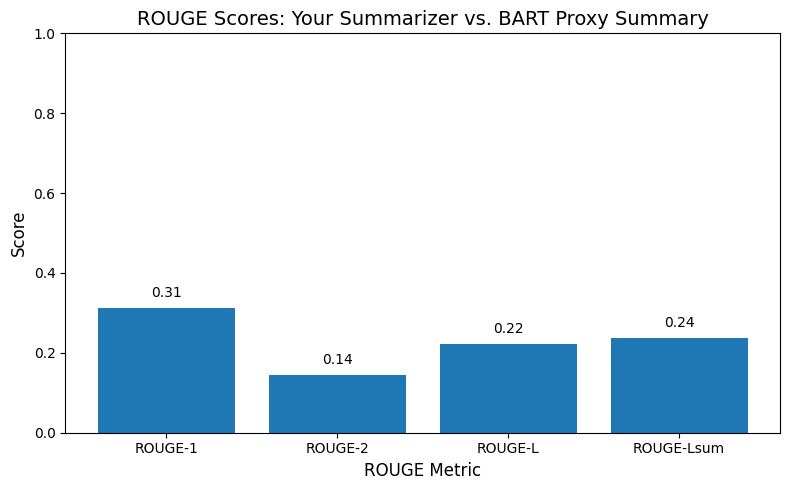

In [ ]:
# Use existing 'results' variable
labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'ROUGE-Lsum']
keys = ['rouge1', 'rouge2', 'rougeL', 'rougeLsum']
scores = [float(results[k]) for k in keys]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, scores)

plt.title("ROUGE Scores: Your Summarizer vs. BART Proxy Summary", fontsize=14)
plt.xlabel("ROUGE Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, score + 0.02, f"{score:.2f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()



In [10]:
df[['proxy_summary', 'my_summary']].to_csv("summary_comparison.csv", index=False)


storing the frequency of the transformer generated data and adding it as context to our summarizer

